--- Limpieza Iniciada ---
Limpieza completada exitosamente. Sin valores nulos residuales.


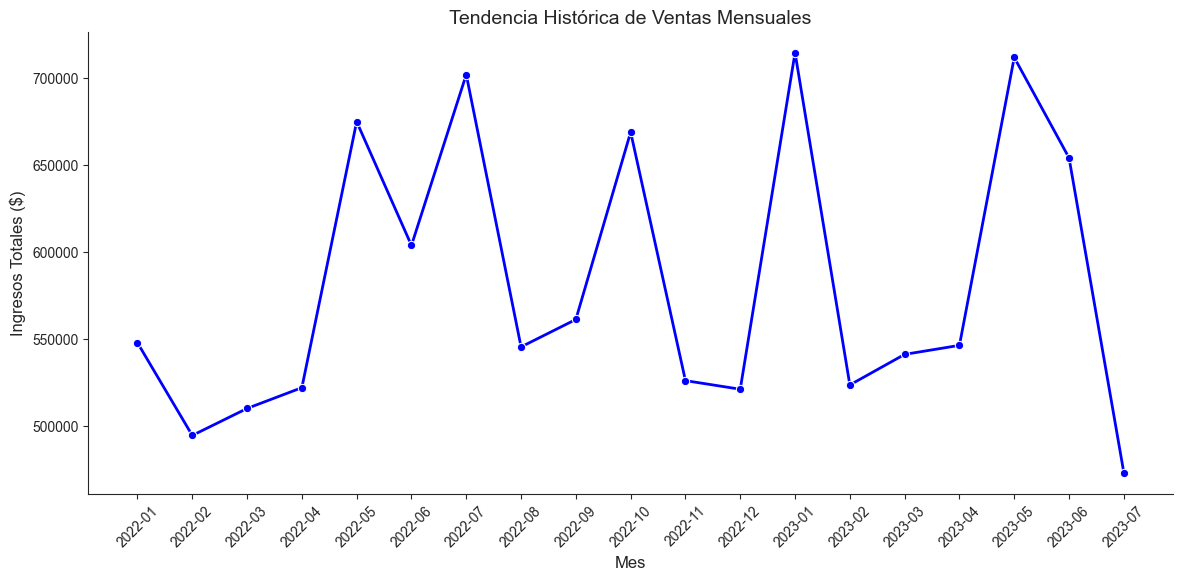

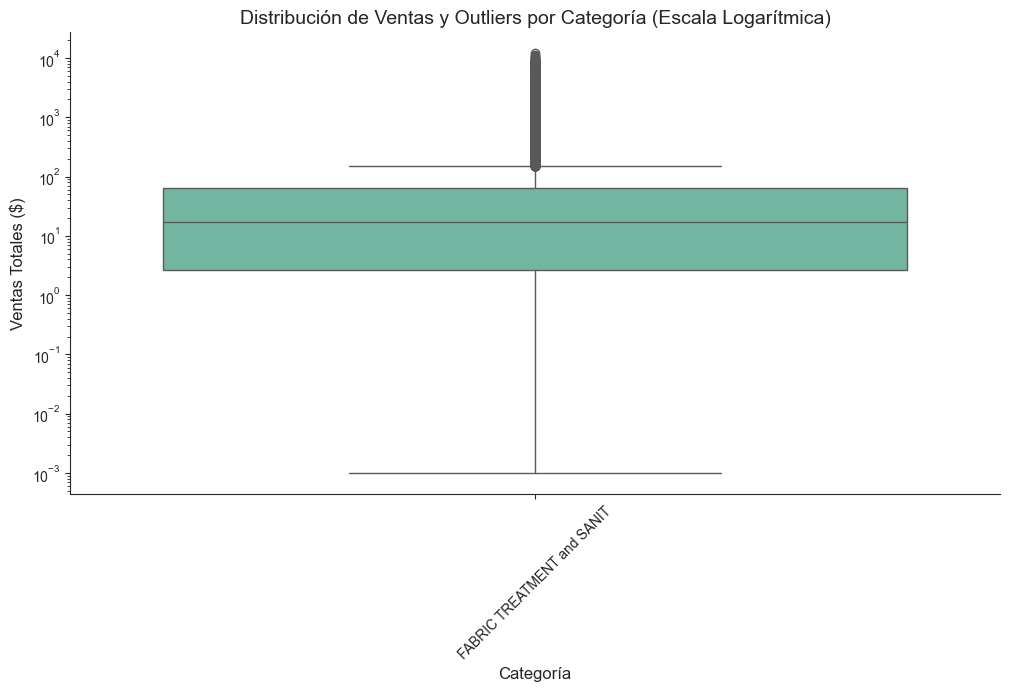

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style("ticks")

# 1. INGESTA DE DATOS
ruta = r"C:\Users\Yamil\OneDrive\Escritorio\Escritorio\Yamil\EBAC (CIENCIA DE DATOS)\Bloque 10 Storytelling y casos de Éxito\MOD 1 Storytelling\Entregable 6\\"

fact_sales = pd.read_csv(ruta + 'FACT_SALES.csv')
dim_cal = pd.read_csv(ruta + 'DIM_CALENDAR.csv')
dim_cat = pd.read_csv(ruta + 'DIM_CATEGORY.csv')
dim_prod = pd.read_csv(ruta + 'DIM_PRODUCT.csv')
dim_seg = pd.read_csv(ruta + 'DIM_SEGMENT.csv')

# 2. LIMPIEZA DE DATOS
print("--- Limpieza Iniciada ---")

# a) Limpieza de caracteres de salto de línea en ID_CATEGORY 1
dim_cat['CATEGORY'] = dim_cat['CATEGORY'].str.replace('\r\n', '', regex=True).str.strip()

# b) Imputación de valores nulos en dimensiones de producto
dim_prod.fillna('NO DEFINIDO', inplace=True)

# c) Estandarización de formato de fecha
dim_cal['DATE'] = pd.to_datetime(dim_cal['DATE'], format='%d/%m/%Y')

print("Limpieza completada exitosamente. Sin valores nulos residuales.")

# 3. TRANSFORMACIÓN Y CONSOLIDACIÓN (Modelo Estrella a Tabla Maestra)
master_df = pd.merge(fact_sales, dim_cal, on='WEEK', how='inner')
master_df = pd.merge(master_df, dim_prod, left_on='ITEM_CODE', right_on='ITEM', how='left')
master_df = pd.merge(master_df, dim_cat, left_on='CATEGORY', right_on='ID_CATEGORY', how='left', suffixes=('', '_NAME'))
master_df.rename(columns={'CATEGORY_NAME': 'CATEGORY_DESC'}, inplace=True)

# 4. ANÁLISIS EXPLORATORIO DE DATOS (EDA)

# Gráfico 1: Tendencia de Ventas en el Tiempo (Lineplot)
plt.figure(figsize=(14, 6))
df_trend = master_df.groupby(master_df['DATE'].dt.to_period('M'))['TOTAL_VALUE_SALES'].sum().reset_index()
df_trend['DATE'] = df_trend['DATE'].astype(str)

sns.lineplot(data=df_trend, x='DATE', y='TOTAL_VALUE_SALES', marker='o', color='b', linewidth=2)
plt.title('Tendencia Histórica de Ventas Mensuales', fontsize=14)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Ingresos Totales ($)', fontsize=12)
plt.xticks(rotation=45)
sns.despine()
plt.show()

# Gráfico 2: Detección de Outliers por Categoría (Boxplot)
plt.figure(figsize=(12, 6))
grafico_dist = sns.boxplot(data=master_df, x='CATEGORY_DESC', y='TOTAL_VALUE_SALES', palette='Set2')
grafico_dist.set_yscale("log") 

plt.title('Distribución de Ventas y Outliers por Categoría (Escala Logarítmica)', fontsize=14)
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Ventas Totales ($)', fontsize=12)
plt.xticks(rotation=45)
sns.despine()
plt.show()

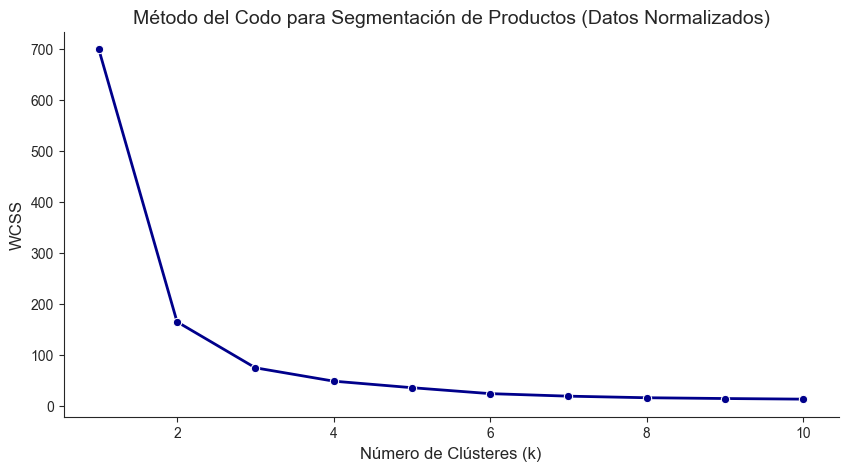

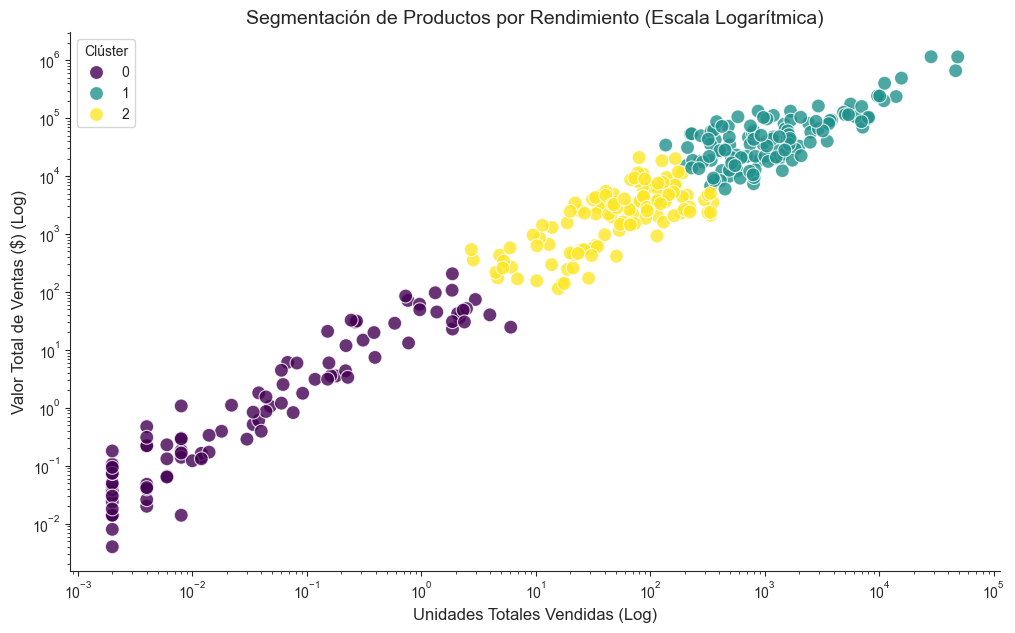

--- Perfil Promedio de los Clústeres (En ventas reales $) ---
   CLUSTER  TOTAL_UNIT_SALES  TOTAL_VALUE_SALES
0        0          0.439080          14.000520
1        1       3000.362913       83428.799323
2        2         86.749837        3626.035179


In [3]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. PREPARACIÓN DE DATOS 
df_cluster = master_df.groupby(['ITEM_CODE', 'BRAND'])[['TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES']].sum().reset_index()

# 🌟 EL TRUCO ESTRELLA: Transformación Logarítmica (log1p maneja bien los ceros)
df_cluster['LOG_UNIT'] = np.log1p(df_cluster['TOTAL_UNIT_SALES'])
df_cluster['LOG_VALUE'] = np.log1p(df_cluster['TOTAL_VALUE_SALES'])

X_log = df_cluster[['LOG_UNIT', 'LOG_VALUE']]

# Estandarización de los datos logarítmicos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# 2. MÉTODO DEL CODO (Actualizado)
wcss = []
rango_k = range(1, 11)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
sns.lineplot(x=list(rango_k), y=wcss, marker='o', color='darkblue', linewidth=2)
plt.title('Método del Codo para Segmentación de Productos (Datos Normalizados)', fontsize=14)
plt.xlabel('Número de Clústeres (k)', fontsize=12)
plt.ylabel('WCSS', fontsize=12)
sns.despine()
plt.show()

# 3. ENTRENAMIENTO DEL MODELO K-MEANS 
# Al aplicar logaritmo, k=3 segmentará perfectamente en: Bajo, Medio y Alto Rendimiento
kmeans_final = KMeans(n_clusters=3, random_state=42)
df_cluster['CLUSTER'] = kmeans_final.fit_predict(X_scaled)

# 4. VISUALIZACIÓN DE LOS CLÚSTERES (Scatter Plot con Escala Logarítmica)
plt.figure(figsize=(12, 7))
# Graficamos los datos reales, pero forzamos a los ejes a comportarse de forma logarítmica
sns.scatterplot(data=df_cluster, x='TOTAL_UNIT_SALES', y='TOTAL_VALUE_SALES', hue='CLUSTER', palette='viridis', s=100, alpha=0.8)

plt.xscale('log') # Eje X en logaritmo
plt.yscale('log') # Eje Y en logaritmo

plt.title('Segmentación de Productos por Rendimiento (Escala Logarítmica)', fontsize=14)
plt.xlabel('Unidades Totales Vendidas (Log)', fontsize=12)
plt.ylabel('Valor Total de Ventas ($) (Log)', fontsize=12)
plt.legend(title='Clúster')
sns.despine()
plt.show()

# 5. RESUMEN EJECUTIVO DE CENTROIDES
resumen_clusters = df_cluster.groupby('CLUSTER')[['TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES']].mean().reset_index()
print("--- Perfil Promedio de los Clústeres (En ventas reales $) ---")
print(resumen_clusters)

--- RE-ENTRENAMIENTO DEFINITIVO: MODELOS PREDICTIVOS ---


C:\Users\Yamil\anaconda3\envs\mi_entorno\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Yamil\anaconda3\envs\mi_entorno\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)



--- EVALUACIÓN DE MODELOS ---
SARIMA             -> MAE: $82,855.27
Regresión Múltiple -> MAE: $82,779.06


C:\Users\Yamil\anaconda3\envs\mi_entorno\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Yamil\anaconda3\envs\mi_entorno\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


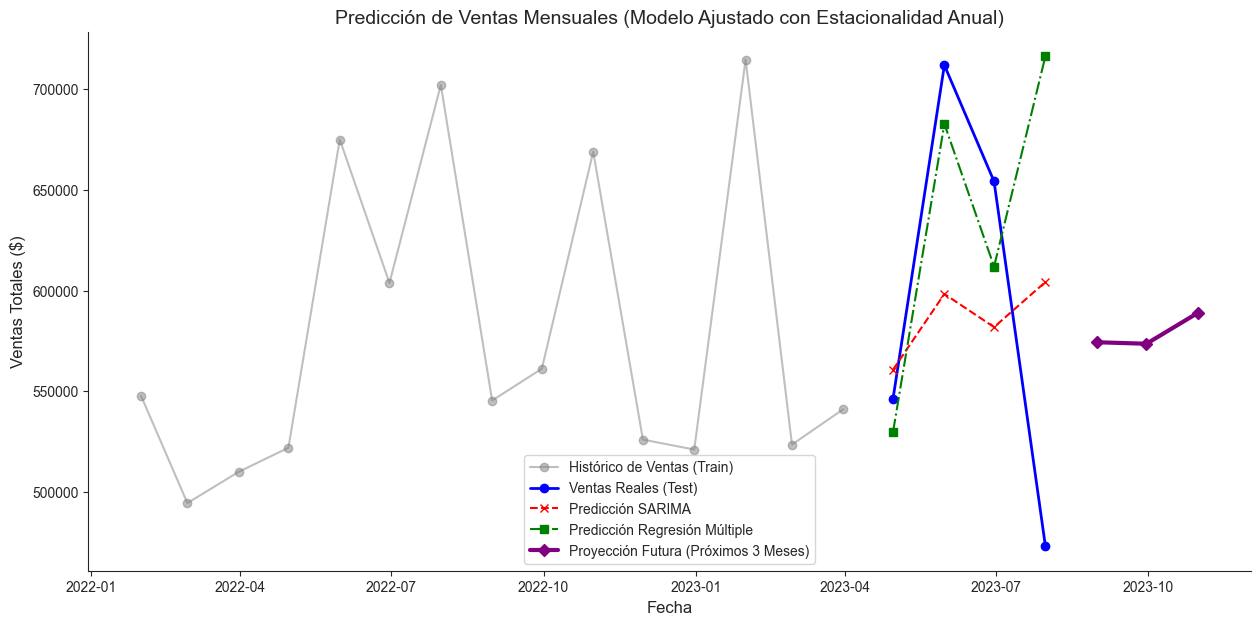

In [7]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np

print("--- RE-ENTRENAMIENTO DEFINITIVO: MODELOS PREDICTIVOS ---")

# 1. SUAVIZADO MENSUAL
df_ts = master_df.groupby(pd.Grouper(key='DATE', freq='ME'))['TOTAL_VALUE_SALES'].sum().reset_index()
df_ts.set_index('DATE', inplace=True)

y_log = np.log1p(df_ts['TOTAL_VALUE_SALES'])
split_point = int(len(y_log) * 0.8)
train_y, test_y = y_log.iloc[:split_point], y_log.iloc[split_point:]

# -------------------------------------------------------------------
# 2. MODELO 1: SARIMA (¡AQUÍ ESTABA EL ERROR: Agregamos la "S" de 12 meses!)
# -------------------------------------------------------------------
modelo_sarima = SARIMAX(train_y, order=(1, 1, 1), seasonal_order=(1, 0, 0, 12))
sarima_ajustado = modelo_sarima.fit(disp=False)
predicciones_sarima_log = sarima_ajustado.forecast(steps=len(test_y))
predicciones_sarima = np.expm1(predicciones_sarima_log)

# -------------------------------------------------------------------
# 3. MODELO 2: REGRESIÓN LINEAL MÚLTIPLE (Meses como categorías)
# -------------------------------------------------------------------
df_reg = pd.DataFrame({'LOG_SALES': y_log})
# Hacemos el mes 'texto' y luego Dummies para que el modelo identifique los picos
df_reg['MES'] = df_reg.index.month.astype(str) 
df_reg = pd.get_dummies(df_reg, columns=['MES'], drop_first=True)
df_reg['LAG_1'] = df_reg['LOG_SALES'].shift(1)
df_reg.dropna(inplace=True)

y_reg = df_reg['LOG_SALES']
X_reg = df_reg.drop(columns=['LOG_SALES'])

split_reg = int(len(y_reg) * 0.8)
X_train, X_test = X_reg.iloc[:split_reg], X_reg.iloc[split_reg:]
y_train, y_test = y_reg.iloc[:split_reg], y_reg.iloc[split_reg:]

modelo_rl = LinearRegression()
modelo_rl.fit(X_train, y_train)
predicciones_rl_log = modelo_rl.predict(X_test)
predicciones_rl = np.expm1(predicciones_rl_log)

# -------------------------------------------------------------------
# 4. AUDITORÍA DE ERRORES (Métricas Reales)
# -------------------------------------------------------------------
test_y_real = np.expm1(test_y)
y_test_real = np.expm1(y_test)

mae_sarima = mean_absolute_error(test_y_real, predicciones_sarima)
mae_rl = mean_absolute_error(y_test_real, predicciones_rl)

print("\n--- EVALUACIÓN DE MODELOS ---")
print(f"SARIMA             -> MAE: ${mae_sarima:,.2f}")
print(f"Regresión Múltiple -> MAE: ${mae_rl:,.2f}")

# -------------------------------------------------------------------
# 5. PREDICCIÓN AL FUTURO (Próximos 3 Meses)
# -------------------------------------------------------------------
modelo_futuro = SARIMAX(y_log, order=(1, 1, 1), seasonal_order=(1, 0, 0, 12))
sarima_futuro = modelo_futuro.fit(disp=False)
predicciones_futuro_log = sarima_futuro.forecast(steps=3)
predicciones_futuro = np.expm1(predicciones_futuro_log)

# -------------------------------------------------------------------
# 6. VISUALIZACIÓN FINAL 
# -------------------------------------------------------------------
plt.figure(figsize=(15, 7))

train_y_real = np.expm1(train_y)
plt.plot(train_y_real.index, train_y_real, label='Histórico de Ventas (Train)', color='gray', alpha=0.5, marker='o')
plt.plot(test_y_real.index, test_y_real, label='Ventas Reales (Test)', color='blue', linewidth=2, marker='o')

plt.plot(test_y_real.index, predicciones_sarima, label='Predicción SARIMA', color='red', linestyle='--', marker='x')
plt.plot(y_test_real.index, predicciones_rl, label='Predicción Regresión Múltiple', color='green', linestyle='-.', marker='s')

plt.plot(predicciones_futuro.index, predicciones_futuro, label='Proyección Futura (Próximos 3 Meses)', color='purple', linewidth=3, marker='D')

plt.title('Predicción de Ventas Mensuales (Modelo Ajustado con Estacionalidad Anual)', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Ventas Totales ($)', fontsize=12)
plt.legend()
sns.despine()
plt.show()